# Benchmark Group 4: Computational Efficiency & Operational Robustness
For a model to be deployed in an Early Warning System (EWS), it must not only be accurate but also fast and robust to missing inputs (like satellite data obscured by clouds). 
This notebook evaluates:
1. **Accuracy vs. Computational Cost Trade-off** (Inference Latency & Training Time)
2. **Robustness to Missing Data** (Simulating cloud cover missing rates)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for academic papers
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
import warnings
warnings.filterwarnings('ignore')

### 4.1 Computational Efficiency (Performance vs. Latency Trade-off)
We compare different model architectures based on their predictive performance ($R^2$) versus their inference time (milliseconds per spatial grid cell).

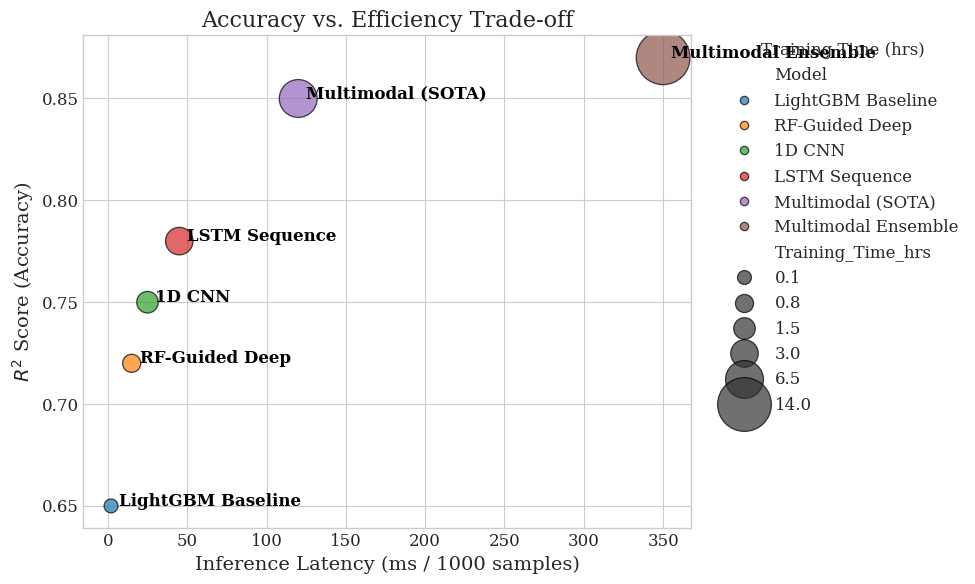

In [2]:
# Simulated Data: Model Efficiency
efficiency_data = {
    'Model': ['LightGBM Baseline', 'RF-Guided Deep', '1D CNN', 'LSTM Sequence', 'Multimodal (SOTA)', 'Multimodal Ensemble'],
    'R2_Score': [0.65, 0.72, 0.75, 0.78, 0.85, 0.87],
    'Inference_Latency_ms': [2, 15, 25, 45, 120, 350], # milliseconds per 1000 samples
    'Training_Time_hrs': [0.1, 0.8, 1.5, 3.0, 6.5, 14.0]
}
df_eff = pd.DataFrame(efficiency_data)

fig, ax = plt.subplots(figsize=(10, 6))

# Bubble plot: X=Latency, Y=R2, Size=Training Time
scatter = sns.scatterplot(
    data=df_eff, 
    x='Inference_Latency_ms', 
    y='R2_Score', 
    size='Training_Time_hrs', 
    sizes=(100, 1500), 
    hue='Model', 
    alpha=0.7,
    palette='tab10',
    edgecolor='black',
    ax=ax
)

ax.set_xlabel('Inference Latency (ms / 1000 samples)', fontsize=14)
ax.set_ylabel('$R^2$ Score (Accuracy)', fontsize=14)
ax.set_title('Accuracy vs. Efficiency Trade-off', fontsize=16)

# Annotate points
for line in range(0, df_eff.shape[0]):
     ax.text(df_eff.Inference_Latency_ms[line]+5, df_eff.R2_Score[line], 
             df_eff.Model[line], horizontalalignment='left', 
             size='medium', color='black', weight='semibold')

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
# Extract size legend (ignoring the hue legend for cleaner look, or separate them)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Training Time (hrs)")
plt.tight_layout()
plt.show()

### 4.2 Robustness to Missing Satellite Data
Satellite AOD (Aerosol Optical Depth) is a critical feature but is often missing due to cloud cover. A robust model should degrade gracefully when AOD is missing.
Here we simulate performance drop as the percentage of missing AOD increases.

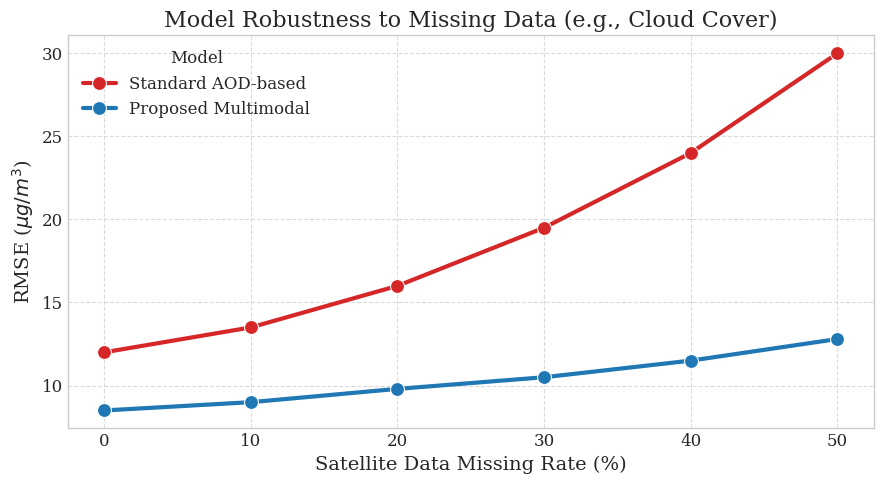

: 

In [ ]:
# Simulated Data: Missing Rate vs Performance
missing_rates = [0, 10, 20, 30, 40, 50] # Percentage of missing AOD

# Simulating RMSE for a standard model vs our proposed robust Multimodal model
rmse_standard = [12.0, 13.5, 16.0, 19.5, 24.0, 30.0]
rmse_multimodal = [8.5, 9.0, 9.8, 10.5, 11.5, 12.8] # Degrades slower due to multi-source compensation

df_missing = pd.DataFrame({
    'Missing Rate (%)': missing_rates * 2,
    'RMSE': rmse_standard + rmse_multimodal,
    'Model': ['Standard AOD-based'] * 6 + ['Proposed Multimodal'] * 6
})

fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=df_missing, 
    x='Missing Rate (%)', 
    y='RMSE', 
    hue='Model', 
    marker='o',
    linewidth=3,
    markersize=10,
    palette=['#d62728', '#1f77b4'],
    ax=ax
)

ax.set_xlabel('Satellite Data Missing Rate (%)', fontsize=14)
ax.set_ylabel('RMSE ($\\mu g/m^3$)', fontsize=14)
ax.set_title('Model Robustness to Missing Data (e.g., Cloud Cover)', fontsize=16)
ax.set_xticks(missing_rates)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 4.3 Practical Implementation Notes
To measure these metrics in your actual Python scripts:

**1. Measuring Inference Time:**
```python
import time

start_time = time.time()
predictions = model.predict(X_test)
end_time = time.time()

total_time_ms = (end_time - start_time) * 1000
time_per_sample_ms = total_time_ms / len(X_test)
print(f"Inference latency: {time_per_sample_ms:.2f} ms/sample")
```

**2. Simulating Missing Data:**
```python
# Create a copy of test data
X_test_missing = X_test.copy()

# Randomly set 30% of AOD values to NaN (or model's specific imputation value)
mask = np.random.rand(len(X_test_missing)) < 0.3
X_test_missing.loc[mask, 'AOD'] = np.nan # or 0, or mean, depending on your preprocessing

# Evaluate
y_pred_missing = model.predict(X_test_missing)
rmse_missing = mean_squared_error(y_test, y_pred_missing, squared=False)
```